<a href="https://colab.research.google.com/github/NigelPetersen/Finite-Element-GP-regression-Simulations/blob/main/FiniteElementGPRegressionSims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import numpy.linalg as la
import random

In [ ]:
# Constructing the desired matrices

def get_Matern_covariance(data, kappa, s):
    """
    data: N x D array of N vectors x_i in R^D
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns a N x N matrix M with M_ij = C_Mat(x_i, x_j)
    """

    dim = data.shape[1]
    nu = s - dim/2
    sigma2 = gamma(nu)/(gamma(s)*(4*np.pi)**(dim/2))
    scalar = sigma2*(2**(1-nu)/gamma(nu))

    # matrix of pairwise distances
    D = kappa*np.linalg.norm(data[:, None] - data[None, :], axis = -1)

    M = np.zeros(D.shape)
    off_diag = (D > 0)
    M[off_diag] = scalar * (D[off_diag] ** nu) * kv(nu, D[off_diag])
    M[~off_diag] = sigma2

    return M

def get_mass_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(1, n_h-1)
    diag = np.full(n_h, 4)
    diag[0] = diag[-1] = 2
    M = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (h/6)*M

"""
def get_lumped_mass_matrix(M, n_h):
    M = get_mass_matrix(n_h)
    return np.diag(M.sum(axis = 1))
"""


def get_stiffness_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(-1, n_h-1)
    diag = np.full(n_h, 2)
    diag[0] = diag[-1] = 1
    G = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (1/h)*G

def get_FE_precision_matrix(M, G, kappa, s):
    """
    M: FE mass matrix with M_ij = <e_{h,i}, e_{h,j}>_2
    M_tilde: Lumped FE mass matrix
    G: FE stiffness matrix with G_{ij} = <grad(e_{h,i}), grad(e_{h,j})>_2
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns the precision matrix (k^2M + G)[M_tilde^{-1}(k^2M+G)]^{s-1}
    """

    M_tilde = np.diag(M.sum(axis = 1))
    block1 = kappa**2 * M + G
    #print("rank of block1 is {r} and dimension is {d}".format(r = la.matrix_rank(block1), d = block1.shape))
    block2 = la.solve(M_tilde, block1)

    #return la.matmul(block1, block2**(s-1))
    return block1 @ la.matrix_power(block2, s-1)

def get_FE_design_matrix(data, n_h, L):
    """
    data: N x D array of N vectors x_i in R^D

    Return N x n_h finite element design matrix S with S_ij = e_j(X_i)
    """

    K = n_h - 1
    h = L/K
    S = np.zeros((data.shape[0], n_h))
    for i in range(data.shape[0]):
        x_i = data[i,:].item()
        j = int(np.floor(x_i/h)) # get index in the partition
        S[i,j] = -x_i/h + j + 1
        S[i, j+1] = x_i/h - j
    return S

In [ ]:
# ground truth and comparison vectors

def get_ground_truth_vector(data, L, kappa, s, M):
    zeta = np.random.multivariate_normal(mean = np.zeros(2*(M+1)), cov = np.eye(2*(M+1)))
    alpha = zeta[:M+1]
    beta = zeta[M+1:]
    cnst = alpha[-1]/(np.sqrt(kappa*L))
    scalar = (np.sqrt(2)*(kappa**(s-0.5)))/np.sqrt(L)

    f_0 = []
    for x in data:
        sum_x = 0
        for i in range(M+1):
            sum_x += ((kappa + ((i*np.pi)/L)**2)**(-s/2))*(alpha[i]*np.cos((i*np.pi*x)/L) + beta[i]*np.sin((i*np.pi*x)/L))
        f_x = cnst + scalar*sum_x
        f_0.append(f_x)

    return np.array(f_0)

In [ ]:
np.random.seed(666)

N = 100
L = 5
kappa = 5
s = 2
tau = 2
M = 500
n_h = 50

data = np.random.uniform(0, L, N)
data = data.reshape((N, 1))
f_0 = get_ground_truth_vector(data, L, kappa, s, M)

def generate_data(N, L, n_h, kappa, s, tau, f_N):
    """
    N: sample size
    L: upper limit of domain
    n_h: number of finite element basis functions
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation
    tau: standard deviation of likelihood for GP regression

    Returns posterior vectors F_cf, F_fe in R^N with data generated from Uniform(0,L)
    """

    f_N = f_N.reshape(f_N.shape[0],)

    # Setting 1: Matern covariance
    I_N = np.eye(N)
    Sigma = get_Matern_covariance(data, kappa, s)
    #f_N = np.random.multivariate_normal(mean = np.zeros(N), cov = Sigma)
    y_cf = np.random.multivariate_normal(mean = f_N, cov = (tau^2)*I_N)
    block1 = Sigma + (tau^2)*I_N
    F_cf = Sigma @ la.solve(block1, y_cf)

    # Setting 2: Finite element
    M, G = get_mass_matrix(n_h, L), get_stiffness_matrix(n_h, L)
    Q = get_FE_precision_matrix(M, G, kappa, s)

    #evals_Q = la.eigvalsh(Q)

    #print("smallest eigenvalue of Q is {v}".format(v = evals_Q[0]))

    S = get_FE_design_matrix(data, n_h, L)

    #print("max row sum in S is {s}".format(s = np.max(S.sum(axis=1))))
    #print("min row sum in S is {s}".format(s = np.min(S.sum(axis=1))))

    w = np.random.multivariate_normal(mean = np.zeros(Q.shape[0]), cov = la.inv(Q))
    y_fe = np.random.multivariate_normal(mean = S @ w, cov = (tau^2)*I_N)
    block2 = S.T @ S + (tau**2)*Q

    #print(np.allclose(block2, S.T @ S + (tau**2)*Q))
    #print("rank of block2 is {r} and dimension is {d}".format(r = la.matrix_rank(block2), d = block2.shape)) # PROBLEM HERE

    #evals_block2 = la.eigvalsh(block2)
    #print("smallest eigenvalue of block2 is {v}".format(v = evals_block2[0]))
    #F_fe = S @ la.inv(block2) @ S.T @ y_fe
    F_fe = S @ la.solve(block2, S.T @ y_fe)

    return np.array([F_cf, F_fe])

2
3.208622025632338 2.3523175316294407
7
3.208622025632338 2.3523246635858253
12
3.208622025632338 2.3523234616174347
17
3.208622025632338 2.3523180047644674
22
3.208622025632338 2.3523180648549227
27
3.208622025632338 2.3523213993577086
32
3.208622025632338 2.3523100696756245
37
3.208622025632338 2.352315501687722
42
3.208622025632338 2.3523307498505934
47
3.208622025632338 2.3523256677752857
52
3.208622025632338 2.352323452888341
57
3.208622025632338 2.3523272647166595
62
3.208622025632338 2.3523183399379923
67
3.208622025632338 2.3523282888479984
72
3.208622025632338 2.35231701772425
77
3.208622025632338 2.35232214755555
82
3.208622025632338 2.352313457765957
87
3.208622025632338 2.352321214479839
92
3.208622025632338 2.352311536777178
97
3.208622025632338 2.352325543653297
102
3.208622025632338 2.35232999636834
107
3.208622025632338 2.352339702963089
112
3.208622025632338 2.3523123689587484
117
3.208622025632338 2.352322864194338
122
3.208622025632338 2.352332714960998
127
3.208622

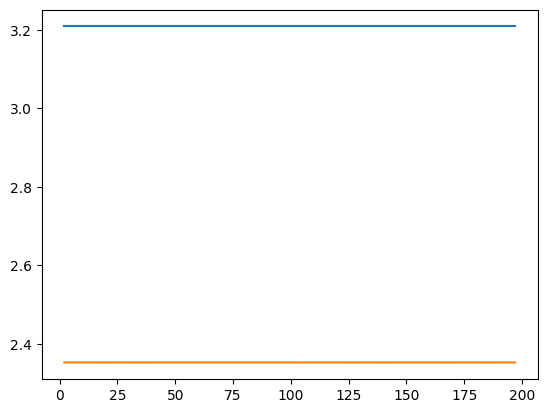

In [ ]:
reps = 20


nums = np.arange(2, 200, 5)
nums = [int(num) for num in nums]
errs_cf, errs_fe = [], []
for n_h in nums:
    print(n_h)
    avg_error_cf, avg_error_fe = 0, 0
    for rep in range(reps):
        F = generate_data(N, L, n_h, kappa, s , tau, f_0)
        F_cf = F[0,:]
        F_fe = F[1,:]

        avg_error_cf += la.norm(F_cf - f_0)/N
        avg_error_fe += la.norm(F_fe - f_0)/N

    errs_cf.append(avg_error_cf/reps)
    errs_fe.append(avg_error_fe/reps)

    print(errs_cf[-1], errs_fe[-1])

plot_data = np.array([nums, errs_cf, errs_fe])
plt.plot(plot_data[0], plot_data[1])
plt.plot(plot_data[0], plot_data[2])

In [ ]:
f_0.reshape(100,)

array([ 3.79849225e+00,  2.70959991e+00,  3.21283185e+00,  4.34257631e+00,
       -4.18717763e-01,  1.15754889e+00, -2.61749520e+00,  1.33778379e+00,
        6.51199939e-01, -1.72234825e+00, -2.62533476e-01,  4.57304520e+00,
       -1.27502845e-01,  3.81457116e+00, -1.06383573e+00,  4.51645866e+00,
        1.30095388e+00,  1.91976547e-01,  2.50018589e-01, -5.67205501e-01,
        1.01533737e+00,  4.33466153e+00, -1.46949807e+00, -2.06726461e-01,
        7.77133077e-01, -6.35601032e-01, -1.08854748e+00, -7.54321403e-01,
        6.24166604e-01, -1.49055396e+00,  1.50018932e+00,  2.22023352e+00,
        3.33046159e+00, -7.71867390e-01, -2.68767580e+00,  4.56251300e+00,
       -1.79736310e+00,  1.74710885e+00,  4.51873026e+00, -4.02507069e-01,
        1.58604642e+00, -3.04412608e+00, -5.71537850e-01,  3.10548364e+00,
       -9.49980722e-02, -9.29022717e-01, -4.44102594e-01,  1.13633925e+00,
        2.22422652e+00, -2.71946721e+00, -2.27388023e+00,  1.08315156e+00,
       -1.11455087e+00, -